In [ ]:
import random
random.seed(42)
import pandas as pd
map_ids = pd.read_csv('/path/to/Identity_CelebA.txt', sep=' ')

all_ids = map_ids["Label"]
train_ids = random.sample(list(all_ids), min(10000, int(len(all_ids) * 0.8)))
val_ids = [x for x in all_ids if x not in train_ids]

In [2]:
len(val_ids) 

51134

In [3]:
import os
root = 'CanFG/data/CelebA/protected_A/'
available_images = set(os.listdir(root))

In [4]:
all_paths = []
with open("/path/to/list_eval_partition.csv", "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        filename, split = line.split(",")
        celeba_name = "img_align_celeba_" + filename.replace(".jpg", ".png")
        if celeba_name not in available_images:
            continue
        all_paths.append(os.path.join(root, celeba_name))


In [ ]:
map_ids_dict = map_ids.to_dict(orient="list")
map_ids_dict = dict(zip(map_ids_dict["Image_name"], map_ids_dict["Label"]))

In [7]:
selected_paths = all_paths

train_path = []
val_path = []
id_tracking = {}
for path in selected_paths:
    img_name = os.path.basename(path)
    row = map_ids_dict.get(img_name.replace(".png", ".jpg").replace("img_align_celeba_", ""))
    if row is None:
        continue
    id_val = row
    if id_tracking.get(id_val, 0) >= 3:
        continue
    if id_val in train_ids:
        train_path.append(path)
    elif id_val in val_ids:
        val_path.append(path)
    id_tracking[id_val] = id_tracking.get(id_val, 0) + 1

In [8]:
len(train_path)

17064

In [9]:
import pickle
os.makedirs("log", exist_ok=True)
with open("log/train_paths.pkl", "wb") as f:
    pickle.dump(train_path, f)
with open("log/val_paths.pkl", "wb") as f:
    pickle.dump(val_path, f)

In [10]:
len(train_path)

17064

In [16]:
from insightface.app import FaceAnalysis
import cv2
import numpy as np
app = FaceAnalysis(name='antelopev2', root='../fracface', providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(128, 128))

def get_embedding(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Failed to read image", image_path)
        return None
    image = cv2.resize(image, (128, 128))
    faces = app.get(image)
    if len(faces) == 0:
        print("No face found in", image_path)
        return None
    return faces[0].embedding.astype(np.float32)

root = 'CanFG/data/CelebA/protected_A/'
available_images = set(os.listdir(root))

 

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../fracface/models/antelopev2/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../fracface/models/antelopev2/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../fracface/models/antelopev2/arcface.onnx recognition ['None', 3, 112, 112] 127.5 127.5
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../fracface/models/antelopev2/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ../fracface/models/antelopev2/scrfd_10g_bnkps.onnx detection [1, 3, '?', '?'] 127.5 128.0
set det-size: (128, 128)


In [17]:
import tqdm
import numpy as np
import multiprocessing as mp
from functools import partial

def process_path(path):
    emb = get_embedding(path.replace("CanFG/data/CelebA/protected_A/img_align_celeba_", "/path/to/celeba_aligned/").replace("png", "jpg"))
    if emb is None:
        return path, np.zeros(512, dtype=np.float32), True
    return path, emb, False

all_paths_to_process = train_path + val_path

with mp.Pool(40) as pool:
    results = list(tqdm.tqdm(pool.imap(process_path, all_paths_to_process), total=len(all_paths_to_process), desc="Extracting embeddings"))

embeddings = {}
failed = 0
for path, emb, did_fail in results:
    embeddings[path] = emb
    if did_fail:
        failed += 1

print(f"Done. {len(embeddings)} embeddings extracted, {failed} failed.")

with open("log/teacher_embeddings_insight.pkl", "wb") as f:
    pickle.dump(embeddings, f)

print("Saved to log/teacher_embeddings_insight.pkl")

Extracting embeddings:  34%|███▍      | 9181/27103 [03:37<07:03, 42.31it/s]

No face found in /path/to/celeba_aligned/051020.jpg


Extracting embeddings:  79%|███████▉  | 21483/27103 [08:29<02:40, 35.11it/s]

No face found in /path/to/celeba_aligned/049777.jpg


Extracting embeddings:  96%|█████████▌| 26049/27103 [10:17<00:28, 37.26it/s]

No face found in /path/to/celeba_aligned/179226.jpg


Extracting embeddings: 100%|██████████| 27103/27103 [10:42<00:00, 42.19it/s]


Done. 27103 embeddings extracted, 3 failed.
Saved to log/teacher_embeddings_insight.pkl


In [29]:
import tqdm
import numpy as np
import multiprocessing as mp
from functools import partial

def process_path(path):
    emb = get_embedding(path)
    if emb is None:
        return path, np.zeros(512, dtype=np.float32), True
    return path, emb, False

all_paths_to_process = val_path

with mp.Pool(40) as pool:
    results = list(tqdm.tqdm(pool.imap(process_path, all_paths_to_process), total=len(all_paths_to_process), desc="Extracting embeddings"))

embeddings = {}
failed = 0
for path, emb, did_fail in results:
    embeddings[path] = emb
    if did_fail:
        failed += 1

print(f"Done. {len(embeddings)} embeddings extracted, {failed} failed.")

with open("log/teacher_embeddings_insight.pkl", "wb") as f:
    pickle.dump(embeddings, f)

print("Saved to log/protected_embeddings.pkl")

Extracting embeddings:  59%|█████▉    | 5910/10039 [02:24<01:29, 46.24it/s]

No face found in CanFG/data/CelebA/protected_A/img_align_celeba_076367.png


Extracting embeddings: 100%|██████████| 10039/10039 [04:06<00:00, 40.79it/s]


Done. 10039 embeddings extracted, 1 failed.
Saved to log/protected_embeddings.pkl


In [18]:
selected_paths = all_paths

train_path = []
val_path = []
id_tracking = {}
for path in selected_paths:
    img_name = os.path.basename(path)
    row = map_ids_dict.get(img_name.replace(".png", ".jpg").replace("img_align_celeba_", ""))
    if row is None:
        continue
    id_val = row
    if len(id_tracking.get(id_val, [])) >= 3:
        continue
    if id_val in train_ids:
        train_path.append(path)
    elif id_val in val_ids:
        val_path.append(path)
    id_tracking[id_val] = id_tracking.get(id_val, []) + [path]

In [19]:
import numpy as np
from PIL import Image

def vstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = max([img.size[0] for img in images])
    height = sum([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    y_pos = 0
    for img in images:
        stacked.paste(img, (0, y_pos))
        y_pos += img.size[1]
    return stacked


def hstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = sum([img.size[0] for img in images])
    height = max([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    x_pos = 0
    for img in images:
        stacked.paste(img, (x_pos, 0))
        x_pos += img.size[0]
    return stacked


In [20]:
from io import BytesIO
import requests
def compare_faces(img1, img2, api_key, api_secret):
    buf1 = BytesIO()
    img1.save(buf1, format="JPEG")
    buf1.seek(0)

    buf2 = BytesIO()
    img2.convert("RGB").save(buf2, format="JPEG")
    buf2.seek(0)

    files = {
        "image_file1": ("img1.jpg", buf1, "image/jpeg"),
        "image_file2": ("img2.jpg", buf2, "image/jpeg")
    }

    data = {
        "api_key": api_key,
        "api_secret": api_secret
    }

    r = requests.post(
        "https://api-us.faceplusplus.com/facepp/v3/compare",
        data=data,
        files=files
    )
    return r.json()


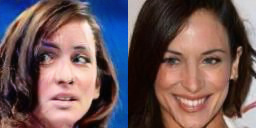

In [21]:
from PIL import Image 
hstack([Image.open(id_tracking[2][0]), Image.open(id_tracking[2][1])])

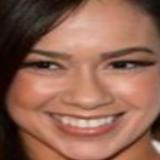

In [22]:
Image.open(id_tracking[2][1].replace("CanFG/data/CelebA/protected_A/img_align_celeba_", "/path/to/celeba_aligned/").replace("png", "jpg"))

In [23]:
compare_faces(Image.open(id_tracking[39][0]), Image.open(id_tracking[39][1]), "YOUR_FACEPP_API_KEY", "YOUR_FACEPP_API_SECRET")


{'request_id': '1774841000,fec22f55-d981-43d0-971b-6ecd167a254e',
 'time_used': 279,
 'confidence': 71.676,
 'thresholds': {'1e-3': 62.327, '1e-4': 69.101, '1e-5': 73.975},
 'faces1': [{'face_token': '2475ea9f47541f2d86e90d1327422210',
   'face_rectangle': {'top': 45, 'left': 32, 'width': 78, 'height': 78}}],
 'faces2': [{'face_token': 'e87d1b73cf288217ad74cb6aa0f06d68',
   'face_rectangle': {'top': 44, 'left': 13, 'width': 81, 'height': 81}}],
 'image_id1': 'MiM6EhBX80uHMjgpUFMz8g==',
 'image_id2': 'NNja4nDMxYF7AGb+2MdYIw=='}

In [24]:
emb2 = get_embedding(id_tracking[36][0])
emb1 = get_embedding(id_tracking[36][1])

In [25]:
id_tracking[36][0] # this is protected, we extracted the wrong id

'CanFG/data/CelebA/protected_A/img_align_celeba_021995.png'

In [26]:
# .replace("CanFG/data/CelebA/protected_A/img_align_celeba_", "/path/to/celeba_aligned/").replace("png", "jpg"))
# .replace("CanFG/data/CelebA/protected_A/img_align_celeba_", "/path/to/celeba_aligned/").replace("png", "jpg"))

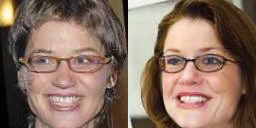

In [27]:
hstack([
    Image.open(id_tracking[36][0]),
    Image.open(id_tracking[36][1])
])

In [28]:
emb1 = emb1 / np.linalg.norm(emb1)
emb2 = emb2 / np.linalg.norm(emb2)
(emb1 * emb2).sum()

np.float32(0.32490206)